# Optimizadores y Regularización: Dominando la Convergencia y la Generalización


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/04_optimizadores_y_regularizacion.ipynb)

## Objetivos


- Diferenciar claramente entre **Optimización** (ajustar los datos de entrenamiento) y **Generalización** (rendir bien en datos nuevos).
- Comprender la física y las matemáticas detrás de los optimizadores modernos: de la lentitud del SGD clásico a la eficiencia de **Momentum, RMSProp y Adam**.
- Entender el sobreajuste (*Overfitting*) como un fallo de generalización.
- Implementar y visualizar el impacto de técnicas de regularización explícita: **Penalización L2 (Weight Decay)** y **Dropout**.



## Prerrequisitos


- Entendimiento del *Backpropagation* y el cálculo de gradientes.
- Haber completado: [Normalización Batch y Layer](03_normalizacion_batch_y_layer.ipynb).

---


## Configuración del Entorno


In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Reproducibilidad estricta
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow versión: {tf.__version__}")

# Verificación de Hardware
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("ADVERTENCIA: No se detectó GPU. El entrenamiento será más lento.")

TensorFlow versión: 2.20.0
ADVERTENCIA: No se detectó GPU. El entrenamiento será más lento.


## 1. El Problema de la Optimización: El Paisaje de Pérdida


Hasta ahora, utilizamos el **Descenso del Gradiente Estocástico (SGD)** clásico (*aunque apareció Adam brevemente también*). La regla de actualización de SGD es simple: calcula la pendiente (gradiente) en la posición actual y da un paso en la dirección opuesta, multiplicado por la tasa de aprendizaje ($\eta$).

$$ w_{nuevo} = w_{actual} - \eta \nabla L $$

**El problema:** Si imaginamos que la función de pérdida es un paisaje montañoso, SGD es como un excursionista con los ojos vendados que solo siente la inclinación del suelo bajo sus pies.
- Si cae en un **valle estrecho**, rebotará de una pared a otra, avanzando muy lentamente hacia el fondo.
- Si llega a un **punto de silla (*saddle point*)** (plano en una dirección, curvo en otra), el gradiente será cercano a cero y el excursionista se detendrá, creyendo erróneamente que ha llegado al fondo absoluto.

Necesitamos dotar a nuestro excursionista de "memoria" y "visión adaptativa".

## 2. La Evolución de los Optimizadores (Física y Matemáticas)



Para resolver las deficiencias de SGD, la comunidad de IA introdujo conceptos de la física clásica y el procesamiento de señales. Va un resumen muy rápido:



### A. SGD con Momentum (Inercia)


En lugar de basar el paso *solo* en el gradiente actual, **Momentum** acumula un promedio móvil de los gradientes pasados.  
> **Analogía:** Es decir, lo podemos imaginar como una piedra bajando por la colina. A medida que baja, gana inercia. Si se topa con un pequeño bache (mínimo local) o una zona plana (punto de silla), su inercia le permite atravesarlo sin detenerse. Además, amortigua las oscilaciones en los barrancos.

### B. RMSProp (Root Mean Square Propagation)


Propuesto por Geoffrey Hinton en una clase de Coursera (literalmente, no hay paper original). RMSProp adapta la tasa de aprendizaje *para cada peso individualmente*. Divide el gradiente por una media móvil de la magnitud de los gradientes recientes.

Si una dirección tiene pendientes extremas (oscilaciones), RMSProp reduce el tamaño del paso en esa dirección. Si una dirección es plana, aumenta el tamaño del paso.



### C. Adam (Adaptive Moment Estimation)


Presentado en 2014, Adam es la fusión definitiva: **Momentum + RMSProp**.
Mantiene un registro tanto de la inercia (primer momento) como de la varianza adaptativa (segundo momento). Es tan robusto que se ha convertido en el estándar por defecto en la mayoría de los proyectos de Deep Learning.

### Visualizaciones

Salvando SGD, es complicado tener una visión intuitiva del comportamiento de cada uno de los optimizadores. Por ello, van algunas visualizaciones con el rendimiento comparativo de varios optimizadores en diferentes funciones de coste.

> **Función de coste con valle profundo**: los algoritmos que escalan el tamaño del paso basados en el gradiente convergen. SGD nunca desciende en la dirección adecuada.

In [ ]:
from IPython.display import Image
Image(url='https://miro.medium.com/v2/resize:fit:786/0*ezD25nEdVBJAeVfA')

> **Función de coste siguiendo el patrón Beale**: debido a lo pronunciado del gradiente en los contornos, los algoritmos acelerados divergen, resultándoles difícil "frenar".

In [ ]:
Image(url='https://miro.medium.com/v2/resize:fit:786/0*-Vu1u-0JFiKYkpOa')

> **Función de coste con forma de silla de montar**: si bien todos los algoritmos acaban convergiendo en las cercanías de un punto de silla, Adadelta/Adagrad/RMSProp lo hacen mucho más rápido.

In [ ]:
Image(url='https://miro.medium.com/v2/resize:fit:786/0*e_iUb1lSX4NSzrcw')

## 3. Experimento 1: Carrera de Optimizadores


Vamos a poner a competir a los 4 algoritmos que abordamos. Entrenamos la misma arquitectura exacta en el dataset Fashion MNIST.

> **⚠️ CRITERIO DE INGENIERÍA:** Para evaluar la capacidad pura de *optimización*, debemos mirar la **Pérdida de Entrenamiento (*Training Loss*)**, no la de validación. El trabajo del optimizador es memorizar los datos de entrenamiento lo más rápido posible. La validación es un problema de generalización (que vemos en la siguiente sección).

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Iniciando la carrera de optimizadores (10 épocas)...
Entrenando con SGD Clásico...
Entrenando con SGD + Momentum...
Entrenando con RMSProp...
Entrenando con Adam...
Carrera finalizada.


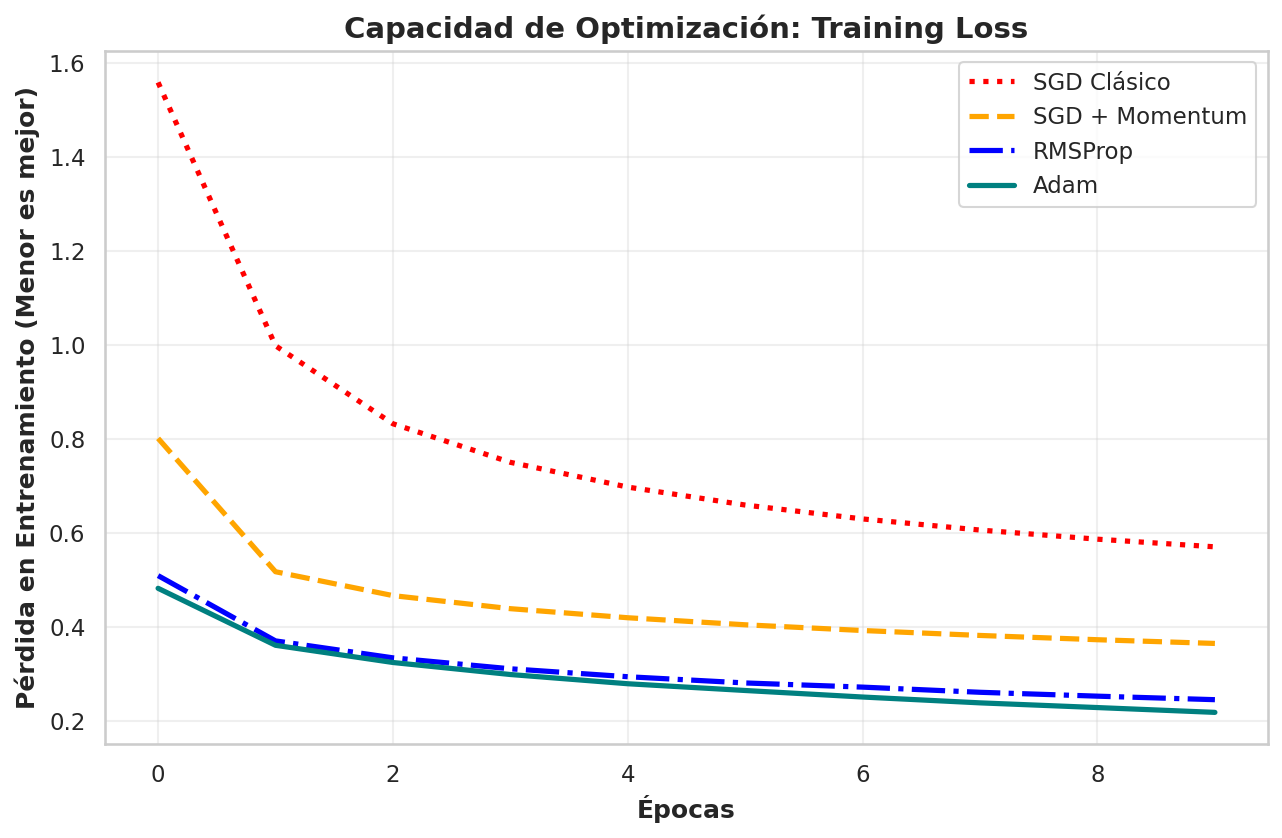

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

# 1. Carga de datos
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Función constructora de un MLP estándar
def construir_modelo():
    modelo = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(256, activation='relu', kernel_initializer='he_normal'),
        Dense(128, activation='relu', kernel_initializer='he_normal'),
        Dense(10, activation='softmax')
    ])
    return modelo

# 3. Definición de Optimizadores (usamos el mismo Learning Rate base para ser justos)
lr = 0.001
optimizadores = {
    'SGD Clásico': SGD(learning_rate=lr),
    'SGD + Momentum': SGD(learning_rate=lr, momentum=0.9),
    'RMSProp': RMSprop(learning_rate=lr),
    'Adam': Adam(learning_rate=lr)
}

historias = {}

# 4. La Carrera
print("Iniciando la carrera de optimizadores (10 épocas)...")
for nombre, opt in optimizadores.items():
    print(f"Entrenando con {nombre}...")
    modelo = construir_modelo()
    modelo.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    # Solo nos importa el train loss para este experimento
    hist = modelo.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)
    historias[nombre] = hist.history['loss']

print("Carrera finalizada.")

# 5. Visualización
plt.figure(figsize=(10, 6))
colores = ['red', 'orange', 'blue', 'teal']
estilos = [':', '--', '-.', '-']

for (nombre, loss), color, estilo in zip(historias.items(), colores, estilos):
    plt.plot(loss, label=nombre, color=color, linestyle=estilo, linewidth=2.5)

plt.title("Capacidad de Optimización: Training Loss", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("Pérdida en Entrenamiento (Menor es mejor)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Análisis de la Carrera



La gráfica ilustra perfectamente la evolución histórica:
- **SGD Clásico (Rojo):** Es lento. Después de 10 épocas, apenas ha comenzado a descender la montaña (*no llega al punto inicial de los mejores...*).
- **SGD + Momentum (Naranja):** La inercia demuestra su valor. Acelera la convergencia respecto al SGD puro.
- **RMSProp (Azul) y Adam (Verde):** Destrozan a la competencia. Al adaptar la tasa de aprendizaje por cada peso, logran encontrar el camino hacia el mínimo de forma casi inmediata. Adam suele tener una ligera ventaja de estabilidad sobre RMSProp.

### Tabla de Decisión MLOps



| Optimizador | Cuándo usarlo | Consideraciones |
| :--- | :--- | :--- |
| **Adam** | **El 90% de las veces.** Punto de partida por defecto. | Rápido y robusto. A veces generaliza un poco peor que SGD en etapas finales. |
| **AdamW** | Entrenando Transformers (LLMs) o usando Weight Decay. | Versión moderna de Adam que corrige un bug matemático con la regularización L2. |
| **SGD + Momentum** | Visión por Computadora (ResNets) en competiciones (Kaggle). | Más lento de afinar, pero a menudo encuentra un mínimo global que generaliza mejor. |
| **RMSProp** | Redes Recurrentes (RNNs, LSTMs). | Fue el estándar para secuencias antes de Adam. |

---



## 4. Regularización: El Arte de no Memorizar


Si Adam es tan bueno minimizando el error, surge un nuevo problema: **El Sobreajuste (*Overfitting*)**.
Una red neuronal profunda con Adam es tan potente que, si la dejamos, memorizará cada píxel del dataset de entrenamiento (incluyendo el ruido), perdiendo la capacidad de predecir datos nuevos.

Entonces, es necesario pasar de la *Optimización* a la **Generalización**. Para evitar la memorización, se suelen incluir obstáculos intencionales durante el entrenamiento: la **Regularización**.

### A. Penalización L2 (Weight Decay)


Añade un costo matemático a la función de pérdida proporcional al cuadrado de los pesos ($\lambda \sum w^2$).  
> **Intuición:** Obliga a la red a mantener sus pesos pequeños y distribuidos. Evita que una sola neurona asuma un peso gigantesco y domine la decisión (lo cual es un síntoma clásico de memorización).



### B. Dropout (El Estándar de la Industria)


Propuesto por Geoffrey Hinton en 2012. Durante cada paso de entrenamiento, **apaga aleatoriamente** un porcentaje de las neuronas (ej. 50%).  
> **Analogía:** Tenemos una empresa donde los empleados se acostumbran a que "Juan" resuelva todos los problemas. Si Juan se enferma, la empresa colapsa (esto se llama *co-adaptación*). `Dropout` obliga a que aleatoriamente la mitad de los empleados falten cada día. Esto fuerza a *todos* los empleados a aprender el negocio central, creando un equipo (*ensamble*) mucho más robusto.


## 5. Experimento 2: Forzando y Curando el *Overfitting*



Para ver el *Overfitting* en acción, necesitamos un escenario propicio:
1. Un dataset pequeño (usamos solo 2.000 imágenes).
2. Una red neuronal masiva (mucha capacidad de memorización).
3. Un optimizador potente (Adam).

Entrenamos un **Modelo Base** (sin regularización) y un **Modelo Regularizado** (con Dropout y L2).

Entrenando Modelo A (Propenso a Overfitting)...
Entrenando Modelo B (Regularizado con Dropout + L2)...
Entrenamientos finalizados.


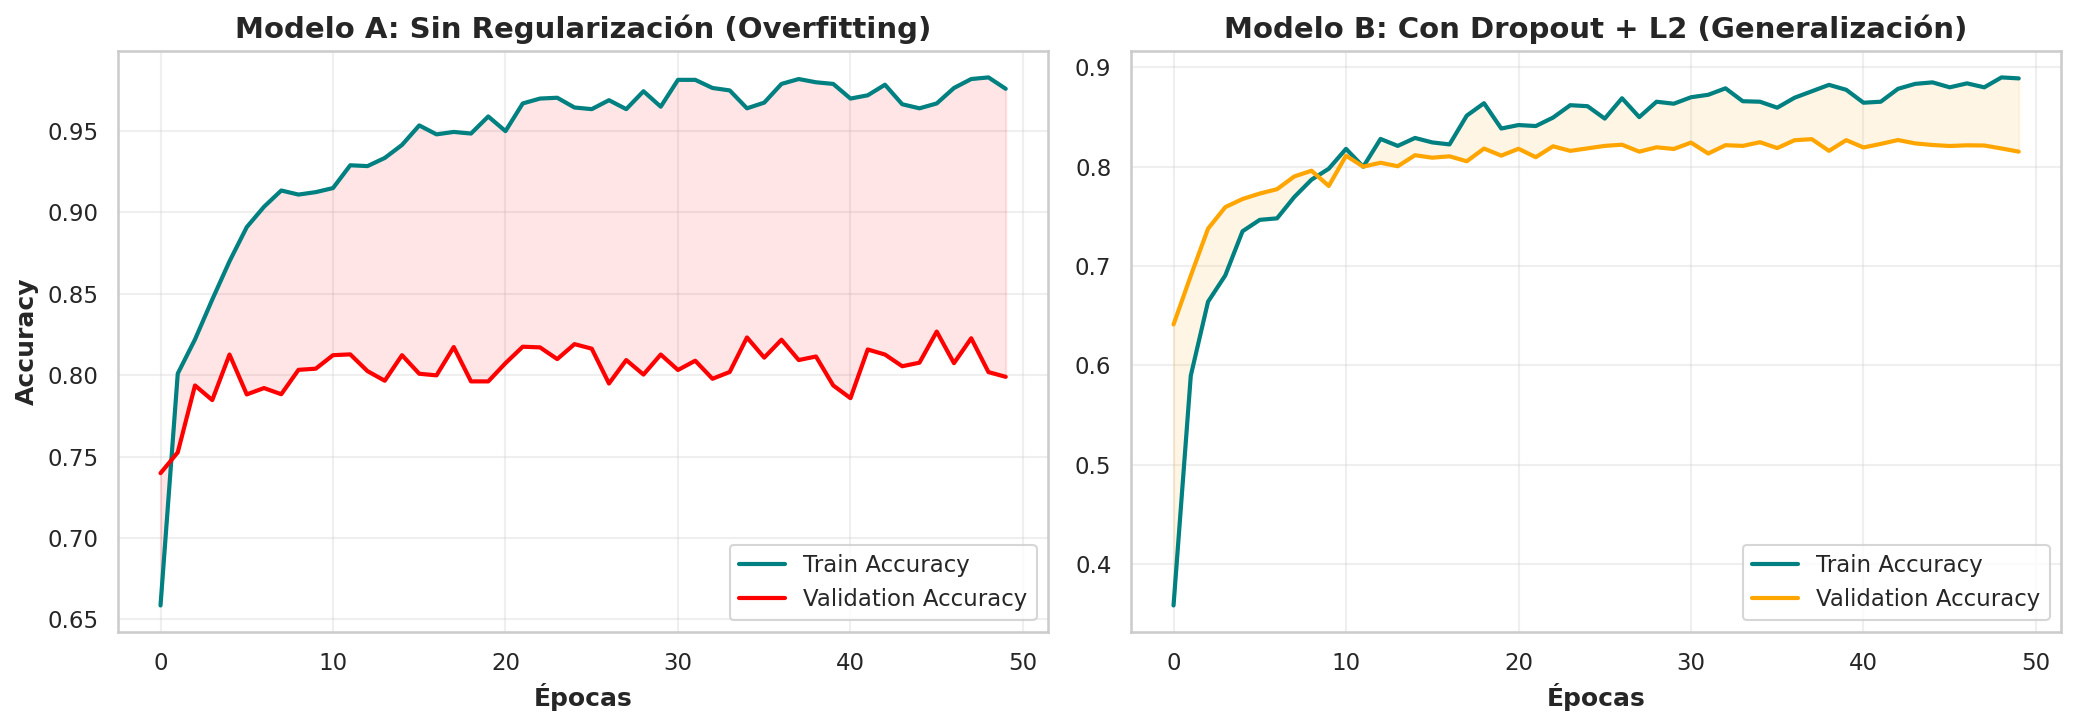

In [5]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

# 1. Creamos un entorno propenso al Overfitting (Pocos datos)
X_train_small = X_train[:2000]
y_train_small = y_train[:2000]

# 2. Modelo A: Red Masiva sin restricciones (Memorizadora)
def construir_modelo_overfit():
    modelo = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(512, activation='relu', kernel_initializer='he_normal'),
        Dense(512, activation='relu', kernel_initializer='he_normal'),
        Dense(512, activation='relu', kernel_initializer='he_normal'),
        Dense(10, activation='softmax')
    ])
    modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo

# 3. Modelo B: Red Masiva con Dropout y L2 (Robusta)
def construir_modelo_regularizado():
    # factor l2 típico: 0.001 o 0.0001
    reg = l2(0.001)

    modelo = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(512, activation='relu', kernel_initializer='he_normal', kernel_regularizer=reg),
        Dropout(0.5), # Apagamos el 50% de las neuronas en cada paso
        Dense(512, activation='relu', kernel_initializer='he_normal', kernel_regularizer=reg),
        Dropout(0.5),
        Dense(512, activation='relu', kernel_initializer='he_normal', kernel_regularizer=reg),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo

# 4. Entrenamiento
print("Entrenando Modelo A (Propenso a Overfitting)...")
modelo_overfit = construir_modelo_overfit()
hist_overfit = modelo_overfit.fit(X_train_small, y_train_small, epochs=50, validation_data=(X_test, y_test), batch_size=64, verbose=0)

print("Entrenando Modelo B (Regularizado con Dropout + L2)...")
modelo_reg = construir_modelo_regularizado()
hist_reg = modelo_reg.fit(X_train_small, y_train_small, epochs=50, validation_data=(X_test, y_test), batch_size=64, verbose=0)
print("Entrenamientos finalizados.")

# 5. Visualización del Diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Modelo A (Overfitting)
axes[0].plot(hist_overfit.history['accuracy'], label='Train Accuracy', color='teal', linewidth=2)
axes[0].plot(hist_overfit.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
axes[0].fill_between(range(50), hist_overfit.history['accuracy'], hist_overfit.history['val_accuracy'], color='red', alpha=0.1)
axes[0].set_title("Modelo A: Sin Regularización (Overfitting)", fontsize=14)
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico Modelo B (Regularizado)
axes[1].plot(hist_reg.history['accuracy'], label='Train Accuracy', color='teal', linewidth=2)
axes[1].plot(hist_reg.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
axes[1].fill_between(range(50), hist_reg.history['accuracy'], hist_reg.history['val_accuracy'], color='orange', alpha=0.1)
axes[1].set_title("Modelo B: Con Dropout + L2 (Generalización)", fontsize=14)
axes[1].set_xlabel("Épocas")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis del Diagnóstico: Leyendo la Brecha


Esta es la habilidad más importante para *deep learning*: **leer la brecha (gap) entre Train y Validation**.

- **Modelo A (Izquierda):** Observar la zona sombreada en rojo. La red alcanza casi un `98%` de precisión en entrenamiento (memorización extrema). Sin embargo, la validación se estanca alrededor del `80-81%` y presenta picos erráticos. Esa brecha masiva es la definición visual del ***Overfitting***. La red está usando su inmensa capacidad para memorizar el ruido de las 2.000 imágenes, lo cual es inútil en producción.
- **Modelo B (Derecha):** Al inyectar caos controlado (*Dropout*) y penalizar pesos grandes (L2), le hacemos la vida imposible a la red durante el entrenamiento. Notar que el *Train Accuracy* sube mucho más lento y se frena cerca del `88%`. **Pero mirar la validación:** es una curva mucho más suave, estable, y alcanza un valor ligeramente superior (`~82%`).

> **⚠️ LA TRAMPA DEL PRINCIPIANTE:** Es común decepcionarse al ver que la regularización "solo subió la validación un 1%". El verdadero éxito aquí no es el número absoluto, sino **la salud del modelo**. El Modelo B logra el mismo poder predictivo real que el Modelo A, pero lo hace *sin necesidad de memorizar ciegamente*. Ha aprendido características generalizables.

> **Nota Técnica sobre Dropout:** Observar las primeras 10 épocas del Modelo B. ¡La validación es superior al entrenamiento! Esto no es un error. Durante el entrenamiento, Keras apaga el 50% de la red (haciendo que rinda peor). Durante la evaluación (`modelo.evaluate`, `modelo.predict` o `val_accuracy`), Keras **enciende toda la red** (**desactiva automáticamente** el *Dropout*) y escala los pesos. Al usar el 100% de su capacidad, la red rinde mejor en validación temporalmente, hasta que el entrenamiento avanza.

## Conexiones y Próximos Pasos


Hasta este punto, tenemos una buena noción respecto a las matemáticas internas de la red: inicialización, normalización, optimización y regularización. Tenemos un motor potente y estable.

Sin embargo, en este notebook entrenamos por un número fijo de épocas (ej. 50). En el mundo real, no sabemos de antemano cuántas épocas tomará converger. Si entrenamos de menos, perdemos rendimiento (*Underfitting*); si entrenamos de más, desperdiciamos dinero en GPU y corremos el riesgo de sobreajustar.

- ➡️ **Siguiente:** Tenemos lo necesario para pasar de la matemática a la **Arquitectura de Software y MLOps**. En el notebook [Ciclo de Entrenamiento y Diagnóstico](05_ciclo_entrenamiento_y_diagnostico.ipynb), aprendemos a automatizar el entrenamiento, leer curvas avanzadas y entender el *Trade-off* del tamaño del lote en la memoria VRAM.

## Referencias


### Artículos Fundacionales

1. **Kingma, D. P., & Ba, J. (2014)**. *Adam: A Method for Stochastic Optimization*. International Conference on Learning Representations (ICLR).  
   [[arXiv]](https://arxiv.org/abs/1412.6980)  
   (Paper original de Adam – uno de los más citados en la historia del Deep Learning).

2. **Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014)**. *Dropout: A Simple Way to Prevent Neural Networks from Overfitting*. Journal of Machine Learning Research (JMLR).  
   [[PDF]](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)  
   (Paper que introdujo Dropout).

3. **Loshchilov, I., & Hutter, F. (2017)**. *Decoupled Weight Decay Regularization (AdamW)*. International Conference on Learning Representations (ICLR).  
   [[arXiv]](https://arxiv.org/abs/1711.05101)  
   (Versión moderna de Adam recomendada en la mayoría de modelos actuales, especialmente Transformers).

### Lecturas Complementarias

- **Goodfellow, I., Bengio, Y., & Courville, A. (2016)**. *Deep Learning* (Capítulo 8: Optimization for Training Deep Models). MIT Press.  
  Disponible gratis en [deeplearningbook.org](https://www.deeplearningbook.org/).

- **Ruder, S. (2016)**. *An overview of gradient descent optimization algorithms*. arXiv preprint.  
  [[arXiv]](https://arxiv.org/abs/1609.04747)  
  (Excelente survey comparativo de optimizadores).

- Documentación oficial:  
  [Keras Optimizers](https://keras.io/api/optimizers/)  
  [Keras Regularizers](https://keras.io/api/layers/regularizers/)

### Recursos Visuales
- 3Blue1Brown – Serie Neural Networks (capítulos sobre optimización).
- Distill.pub – Artículos visuales sobre optimizadores.

---


## Entorno de Ejecución


In [4]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
keras,3.13.2
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
